In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/cleaned/cleaned_online_retail.csv")

How much revenue did the company generate?

In [2]:
total_revenue = df['Revenue'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $8,798,233.74


Basic KPI

In [3]:
print("Total Orders:", df['Invoice'].nunique())
print("Total Customers:", df['Customer ID'].nunique())
print("Total Products:", df['StockCode'].nunique())
print("Total Revenue:", round(df['Revenue'].sum(),2))

Total Orders: 19213
Total Customers: 4312
Total Products: 4017
Total Revenue: 8798233.74


Which months generate the most sales?

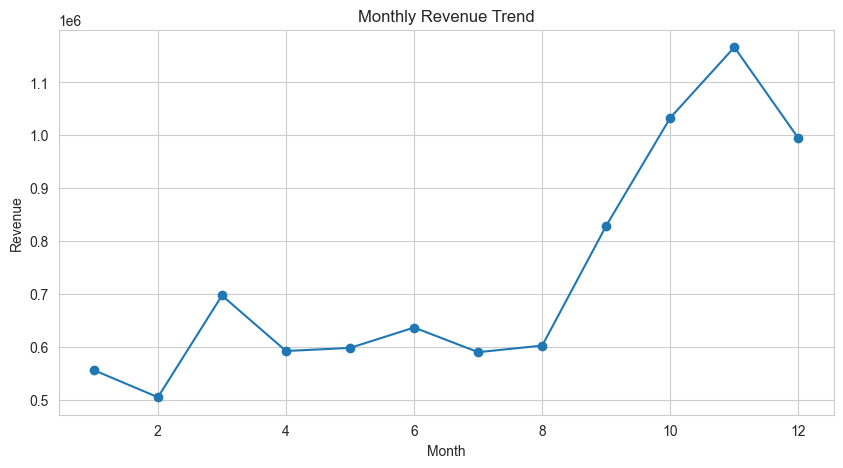

In [4]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

Observation:
Revenue peaks during Month X and Month Y.

Business Insight:
The company should increase inventory and marketing during these months.

Which products generate the most revenue?

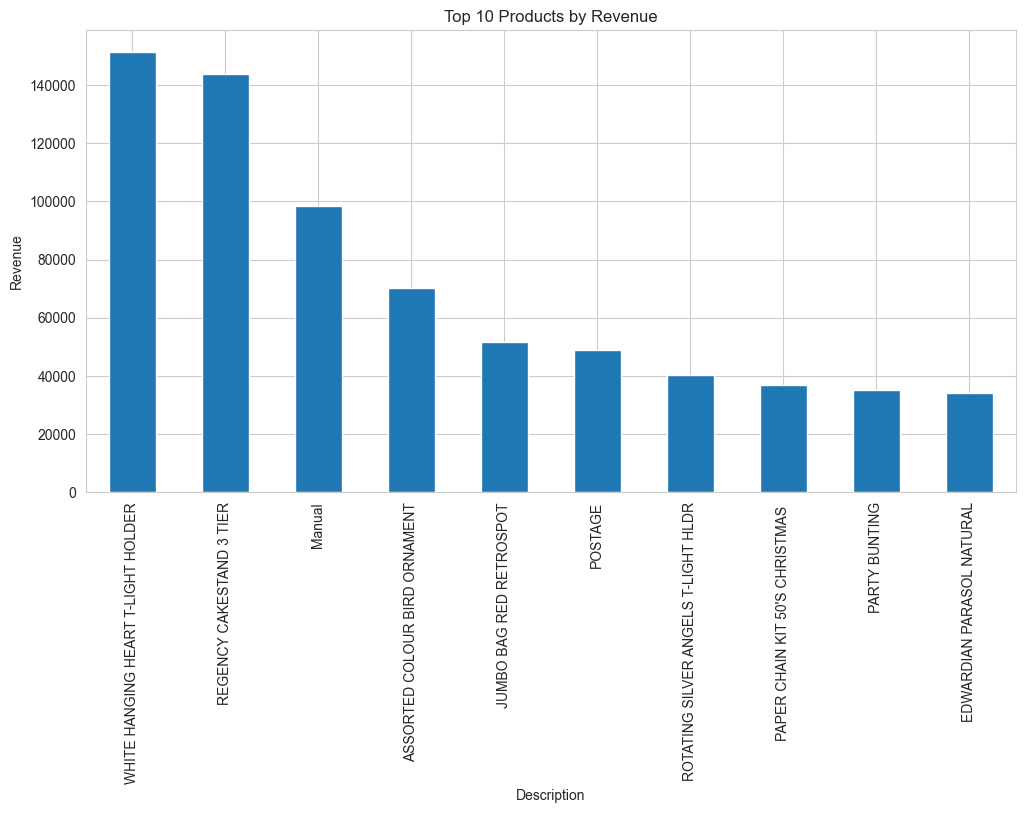

In [5]:
top_products = (
    df.groupby('Description')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

Which countries contribute most revenue?

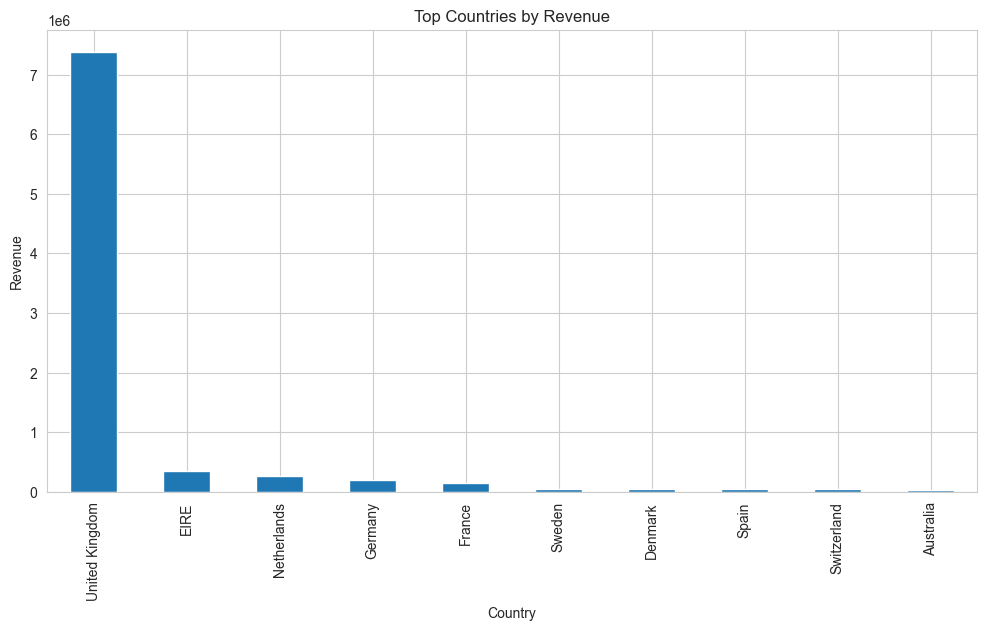

In [6]:
country_sales = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

country_sales.plot(kind='bar')

plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

Who are the biggest spenders?

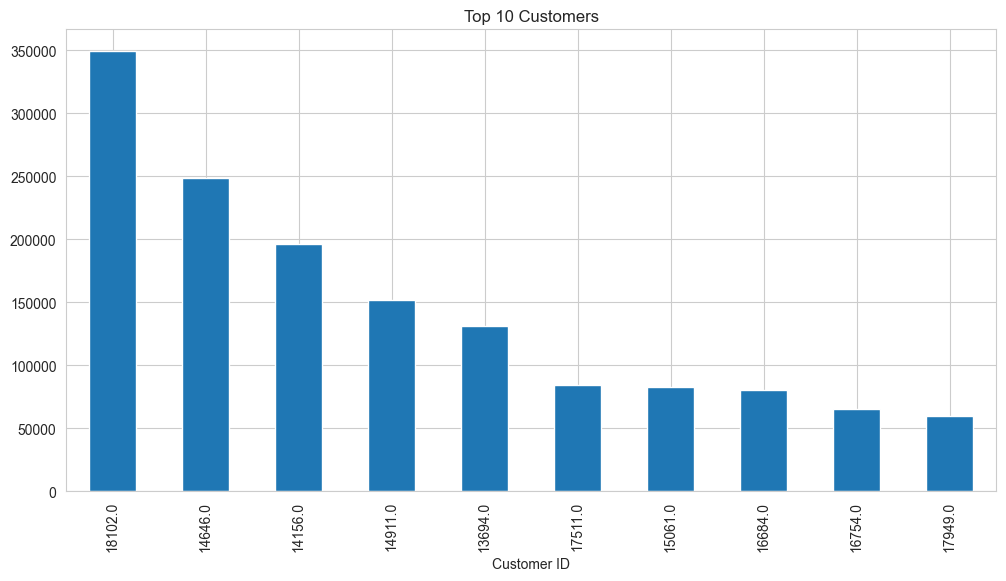

In [7]:
customer_revenue = (
    df.groupby('Customer ID')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

customer_revenue.head(10)

customer_revenue.head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Top 10 Customers")
plt.show()

What does a typical order look like?

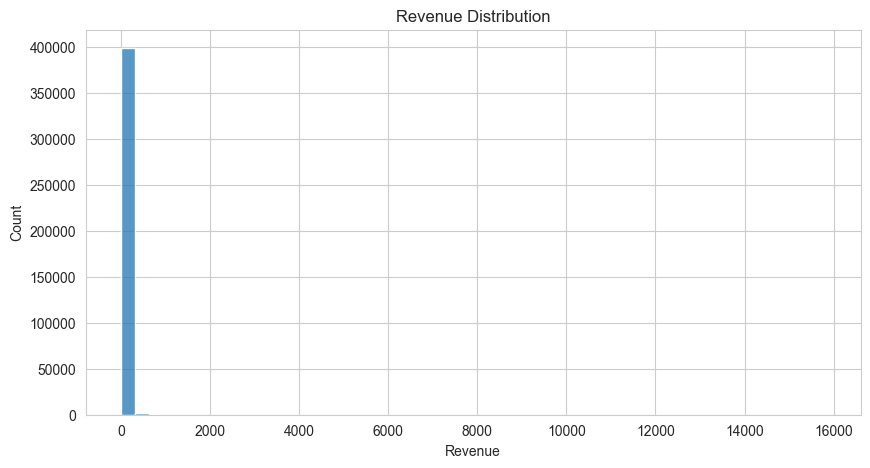

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Revenue'],
    bins=50
)

plt.title("Revenue Distribution")
plt.show()

Quantity Distribution

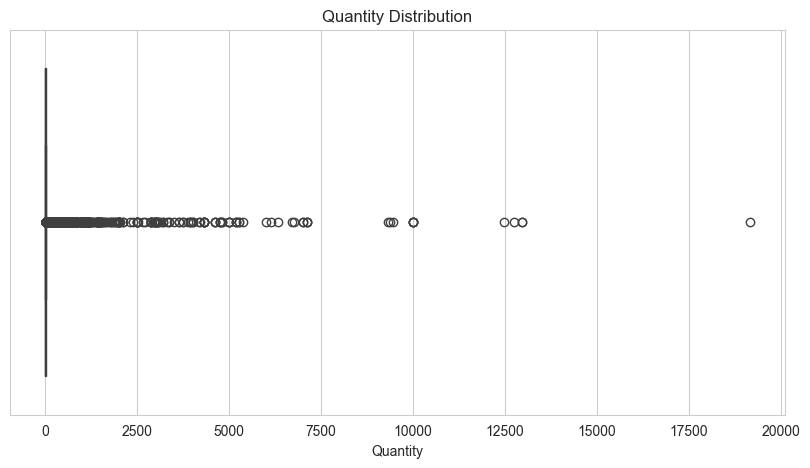

In [9]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Quantity']
)

plt.title("Quantity Distribution")
plt.show()

Revenue by Country Heatmap

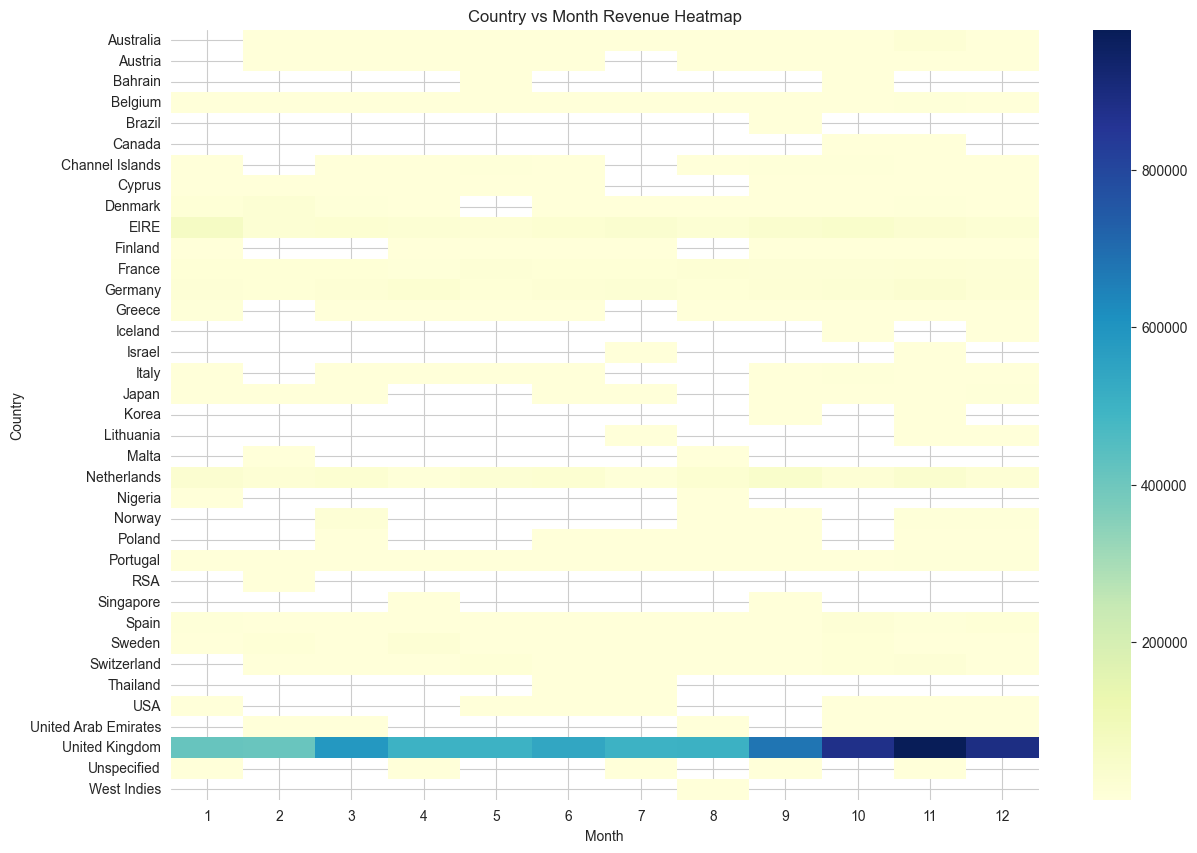

In [10]:
country_month = pd.pivot_table(
    df,
    values='Revenue',
    index='Country',
    columns='Month',
    aggfunc='sum'
)

plt.figure(figsize=(14,10))

sns.heatmap(
    country_month,
    cmap='YlGnBu'
)

plt.title("Country vs Month Revenue Heatmap")
plt.show()

Correlation Analysis

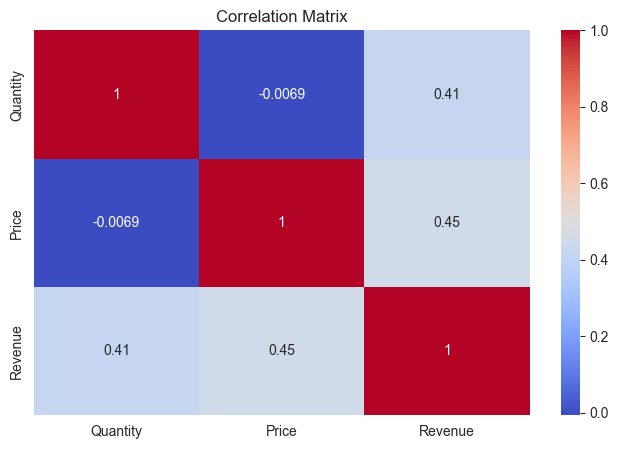

In [11]:
numeric_cols = [
    'Quantity',
    'Price',
    'Revenue'
]

plt.figure(figsize=(8,5))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

Daily Sales Trend

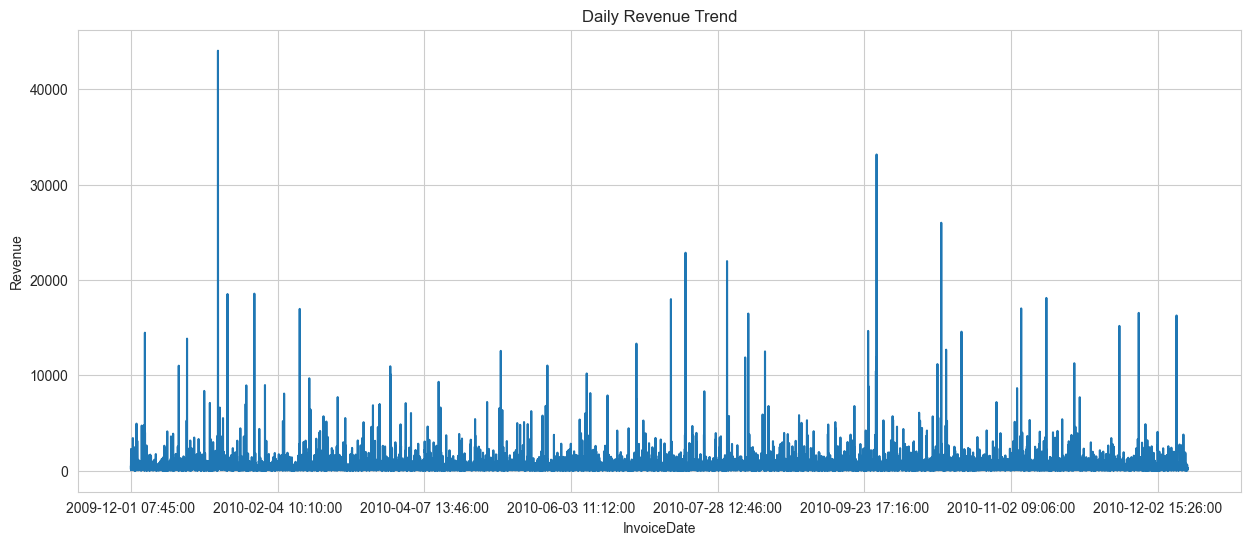

In [12]:
daily_sales = (
    df.groupby('InvoiceDate')['Revenue']
      .sum()
)

plt.figure(figsize=(15,6))

daily_sales.plot()

plt.title("Daily Revenue Trend")
plt.ylabel("Revenue")
plt.show()

How often do customers buy?

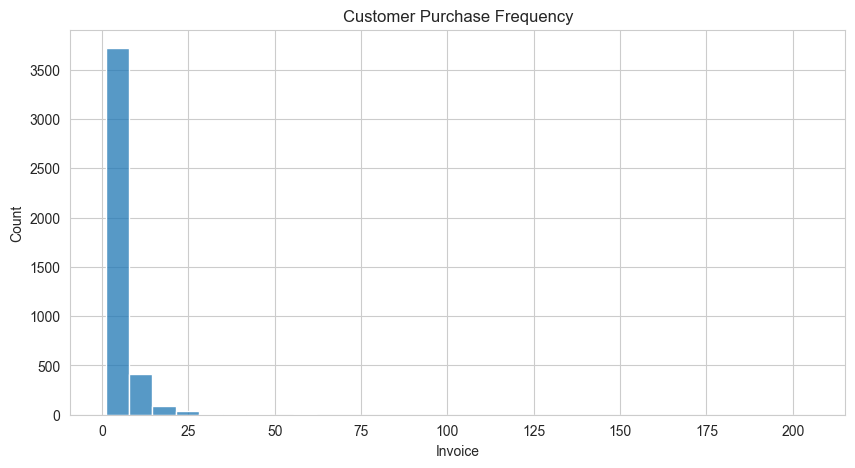

In [25]:
customer_orders = (
    df.groupby('Customer ID')['Invoice']
      .nunique()
)

plt.figure(figsize=(10,5))

sns.histplot(
    customer_orders,
    bins=30
)

plt.title("Customer Purchase Frequency")
plt.show()